# **Latin Grammar Question Intent Classifier**

Fine-tuning a BERT-based model for intent classification to identify user grammatical queries.

## **Import Dependencies**

In [1]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [2]:
import transformers
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset, Dataset
import pandas as pd
import numpy as np
import torch
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
%matplotlib inline

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
os.chdir('/content/drive/MyDrive/FYP')

In [6]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [7]:
print(torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

True
Using device: cuda


## **Prepare Data**

### Load Dataset

In [8]:
DATA_PATH = os.path.join("data_test.csv")

In [9]:
# load necessary columns into df
df = pd.read_csv(DATA_PATH, usecols=['question', 'intent'])
df.head()

,intent,question
0,part_of_speech,Does drivorandum function as a verb?
1,part_of_speech,What is the POS of stanna?
2,part_of_speech,What is the POS of stibadium?
3,part_of_speech,What part of speech is the word dēspicāta?
4,part_of_speech,Does vellende function as a participle?


In [10]:
# dataset summary
print(f"Dataset size: {len(df)} rows")
print(f"Intents: {df['intent'].value_counts().to_dict()}")

Dataset size: 14313 rows
Intents: {'part_of_speech': 5000, 'tense': 3353, 'voice': 3353, 'person': 960, 'mood': 960, 'aspect': 687}


### Split into Train/Test/Validation Sets

In [11]:
# 70% train, 15% test, 15% val
train_df, test_val_df = train_test_split(df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=0.5, random_state=42)

In [12]:
print(len(train_df), "train samples")
print(len(test_df), "test samples")
print(len(val_df), "validation samples")

10019 train samples
2147 test samples
2147 validation samples


### Data Preprocessing

In [13]:
# encode intents as numerical labels
intents = sorted(train_df['intent'].unique())
print("Total number of intents:", len(intents))

intent2label = {intent: i for i, intent in enumerate(intents)} # label mappings
label2intent = {i: intent for i, intent in enumerate(intents)}

print("Intent to Label:", intent2label)
print("Label to Intent:", label2intent)

Total number of intents: 6
Intent to Label: {'aspect': 0, 'mood': 1, 'part_of_speech': 2, 'person': 3, 'tense': 4, 'voice': 5}
Label to Intent: {0: 'aspect', 1: 'mood', 2: 'part_of_speech', 3: 'person', 4: 'tense', 5: 'voice'}


In [14]:
# map intents in df to numerical label
train_df['label'] = train_df['intent'].map(intent2label)
val_df['label']   = val_df['intent'].map(intent2label)
test_df['label']  = test_df['intent'].map(intent2label)

train_df.head()

,intent,question,label
10585,voice,What is the voice of olēscitōte?,5
12026,voice,What voice is muttientī in?,5
2981,part_of_speech,What is the part of speech of cīrētur?,2
9661,tense,"Is circitandus in the present tense, past tens...",4
12498,voice,Which voice is the word ēmercāns in?,5


### Tokenize Dataset

In [15]:
# load tokenizer
# tokenizer = BertTokenizer.from_pretrained("bert-large-uncased")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [16]:
# tokenize function
def tokenize(batch):
    return tokenizer(
        batch["question"],
        truncation=True,
        padding="max_length",
        max_length=50
    )

In [17]:
# convert dataframes to type Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [18]:
# tokenize the dataset
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/10019 [00:00<?, ? examples/s]

Map:   0%|          | 0/2147 [00:00<?, ? examples/s]

Map:   0%|          | 0/2147 [00:00<?, ? examples/s]

In [19]:
print(train_dataset[0])

{'intent': 'voice', 'question': 'What is the voice of olēscitōte?', 'label': 5, '__index_level_0__': 10585, 'input_ids': [101, 2054, 2003, 1996, 2376, 1997, 15589, 11020, 9956, 2618, 1029, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


### Data Visualisation

In [20]:
# get intent counts
intent_counts = df['intent'].value_counts()

labels = intent_counts.index
values = intent_counts.values

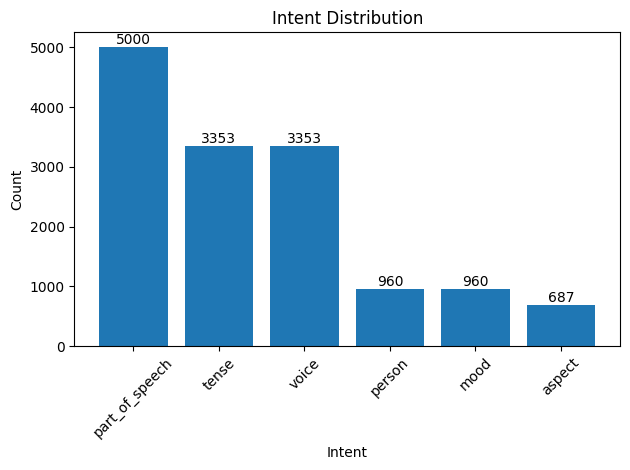

In [21]:
# Bar Chart
plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
  plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom')

plt.xlabel("Intent")
plt.ylabel("Count")
plt.title("Intent Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

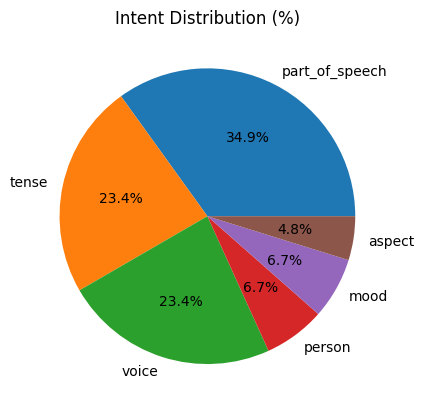

In [22]:
# Pie Chart
plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Intent Distribution (%)")
plt.show()

## **Model**

### Load Model

In [23]:
# model = BertForSequenceClassification.from_pretrained('bert-large-uncased', num_labels=len(intents), id2label=label2intent, label2id=intent2label)
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(intents), id2label=label2intent, label2id=intent2label)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
# define training args
args = TrainingArguments(
    output_dir="./bert_finetuned",          # Directory to save model checkpoints
    eval_strategy="epoch",                  # Evaluate on validation set every epoch
    save_strategy="epoch",                  # Save model checkpoints every epoch
    learning_rate=4e-5,                     # Learning rate
    warmup_steps=0.1,                       # Proportion of training steps to linearly increase learning rate
    per_device_train_batch_size=32,         # Batch size for training
    gradient_accumulation_steps=1,
    num_train_epochs=10,                    # Number of training epochs
    weight_decay=0.01,                      # Regularization to prevent overfitting
    load_best_model_at_end=True,            # Load the best model based on evaluation metrics
    save_total_limit=1,                     # Maximum number of checkpoints to keep - keeps best and most recent
    fp16=True                               # Enable mixed precision for faster training
)

### Training

In [25]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = logits.argmax(axis=1)
  return {
    "accuracy": accuracy_score(labels, preds),
    "f1": f1_score(labels, preds, average="weighted"),
  }

In [26]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [27]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.002345,1.000000,1.000000
2,0.305272,0.000642,1.000000,1.000000
3,0.305272,0.000353,1.000000,1.000000
4,0.000776,0.000239,1.000000,1.000000
5,0.000362,0.000180,1.000000,1.000000
6,0.000362,0.000145,1.000000,1.000000
7,0.000235,0.000124,1.000000,1.000000
8,0.000177,0.000110,1.000000,1.000000
9,0.000177,0.000102,1.000000,1.000000
10,0.000151,0.000099,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3140, training_loss=0.048887387896846435, metrics={'train_runtime': 554.0752, 'train_samples_per_second': 180.824, 'train_steps_per_second': 5.667, 'total_flos': 2574418298742000.0, 'train_loss': 0.048887387896846435, 'epoch': 10.0})

### Plot Training vs Validation Loss Curve

In [29]:
trainer.state.log_history

[{'eval_loss': 0.0023452446330338717,
  'eval_accuracy': 1.0,
  'eval_f1': 1.0,
  'eval_runtime': 4.7238,
  'eval_samples_per_second': 454.503,
  'eval_steps_per_second': 56.945,
  'epoch': 1.0,
  'step': 314},
 {'loss': 0.30527178955078127,
  'grad_norm': 0.011201435700058937,
  'learning_rate': 3.738145789101203e-05,
  'epoch': 1.5923566878980893,
  'step': 500},
 {'eval_loss': 0.0006419151904992759,
  'eval_accuracy': 1.0,
  'eval_f1': 1.0,
  'eval_runtime': 5.2177,
  'eval_samples_per_second': 411.483,
  'eval_steps_per_second': 51.555,
  'epoch': 2.0,
  'step': 628},
 {'eval_loss': 0.0003529492823872715,
  'eval_accuracy': 1.0,
  'eval_f1': 1.0,
  'eval_runtime': 4.2727,
  'eval_samples_per_second': 502.488,
  'eval_steps_per_second': 62.957,
  'epoch': 3.0,
  'step': 942},
 {'loss': 0.0007760129570960998,
  'grad_norm': 0.004298890475183725,
  'learning_rate': 3.0304317055909416e-05,
  'epoch': 3.1847133757961785,
  'step': 1000},
 {'eval_loss': 0.00023901440727058798,
  'eval_ac

In [32]:
# get training log history
log_history = trainer.state.log_history

train_epochs = []
train_loss = []

val_epochs = []
val_loss = []

for entry in log_history:
    # training loss
    if "loss" in entry and "epoch" in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry["loss"])

    # validation loss
    if "eval_loss" in entry:
        val_epochs.append(entry["epoch"])
        val_loss.append(entry["eval_loss"])

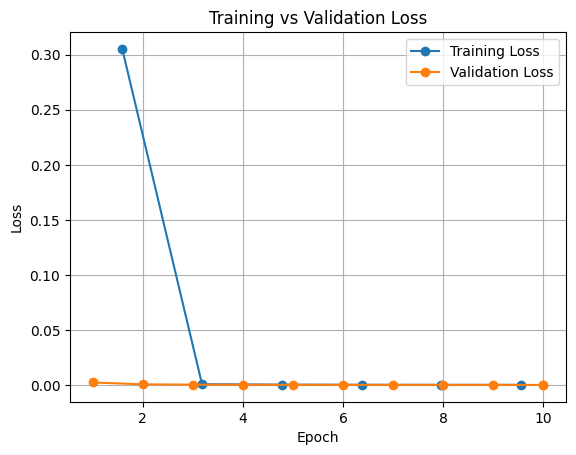

In [35]:
# plot training vs val loss
plt.figure()

plt.plot(train_epochs, train_loss, marker='o', label="Training Loss")
plt.plot(val_epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Evaluate Finetuned Model

In [28]:
# evaluate finetuned model
results = trainer.evaluate()
results

{'eval_loss': 9.8927273938898e-05,
 'eval_accuracy': 1.0,
 'eval_f1': 1.0,
 'eval_runtime': 4.1152,
 'eval_samples_per_second': 521.719,
 'eval_steps_per_second': 65.367,
 'epoch': 10.0}

### Save Model

In [36]:
# save the model and tokenizer
model.save_pretrained("./bert_finetuned")
tokenizer.save_pretrained("./bert_finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert_finetuned/tokenizer_config.json', './bert_finetuned/tokenizer.json')

## **Evaluation**

In [37]:
# load final model and tokenizer
# MODEL_PATH = os.path.join('bert_finetuned', os.listdir('bert_finetuned')[0])
MODEL_PATH = os.path.join('bert_finetuned')

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [38]:
# evaluate model on test set
trainer.evaluate(test_dataset)

{'eval_loss': 9.967093501472846e-05,
 'eval_model_preparation_time': 0.0038,
 'eval_accuracy': 1.0,
 'eval_f1': 1.0,
 'eval_runtime': 9.071,
 'eval_samples_per_second': 236.688,
 'eval_steps_per_second': 29.655}

### Confusion Matrix

In [39]:
# get predictions on test set
pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=1)
labels = pred_output.label_ids

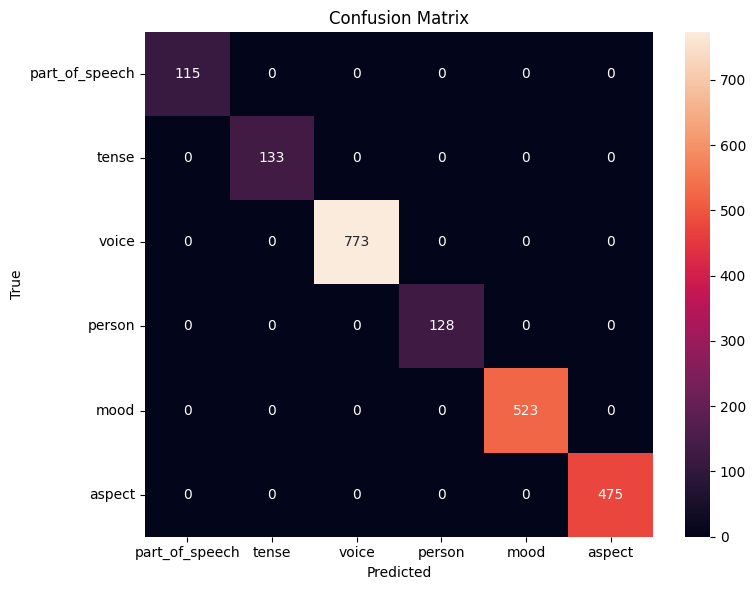

In [40]:
# plot confusion matrix

# create confusion matrix
cm = confusion_matrix(labels, preds)

label_names = intent_counts.index

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=label_names,
            yticklabels=label_names)

plt.xlabel("Predicted")
plt.ylabel("True")
# plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

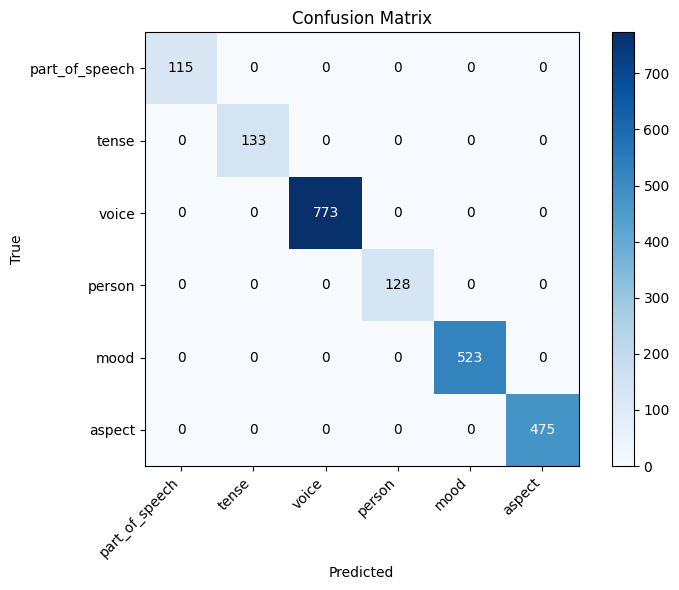

In [41]:
cm = confusion_matrix(labels, preds)

class_names = intent_counts.index

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

# write numbers
thresh = cm.max() / 2  # for choosing text color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, int(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=10
        )

plt.tight_layout()
plt.show()

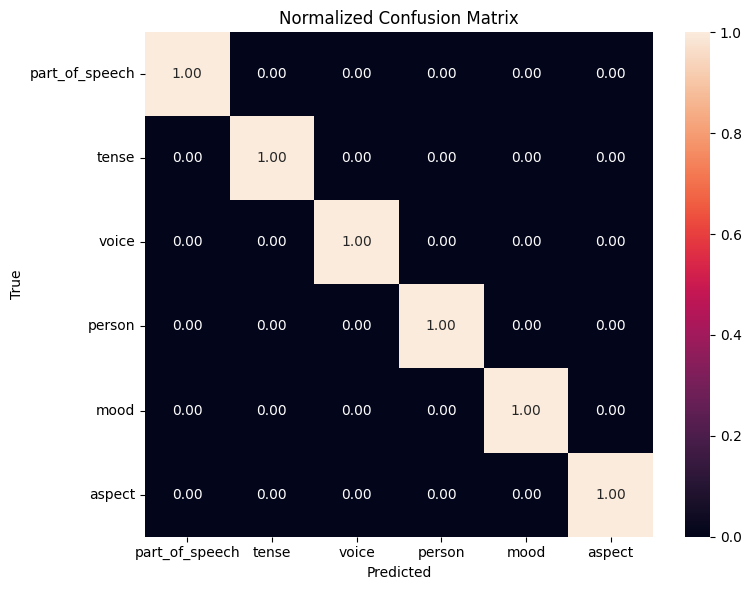

In [42]:
# normalised confusion matrix
cm_norm = confusion_matrix(labels, preds, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm,
            annot=True,
            fmt=".2f",
            xticklabels=label_names,
            yticklabels=label_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.yticks(rotation=0)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

### Classification Report

In [43]:
# classification report
print(classification_report(labels, preds, target_names=label_names))

                precision    recall  f1-score   support

part_of_speech       1.00      1.00      1.00       115
         tense       1.00      1.00      1.00       133
         voice       1.00      1.00      1.00       773
        person       1.00      1.00      1.00       128
          mood       1.00      1.00      1.00       523
        aspect       1.00      1.00      1.00       475

      accuracy                           1.00      2147
     macro avg       1.00      1.00      1.00      2147
  weighted avg       1.00      1.00      1.00      2147

